In [100]:
!pip install seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [101]:
DROP_DUPLICATES_DATA_LINK = "data/2_drop_duplicates_data.csv"
FIX_INVALID_DATA_LINK = "data/3_fix_invalid_data.csv"
import pandas as pd

df = pd.read_csv(DROP_DUPLICATES_DATA_LINK)
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')


In [102]:
for col in df.select_dtypes(include=['object']).columns:
    print("-------",col,"-------")
    print(df[col].unique().tolist())
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    print("-------",col,"-------")
    print("Min:", df[col].min(), "-", "Max:", df[col].max())

C:\Users\Chunwan\AppData\Local\Temp\ipykernel_34212\3273065405.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


------- job -------
['admin.', 'services', 'blue-collar', 'technician', 'housemaid', 'retired', 'management', 'unemployed', 'self-employed', 'unknown', 'entrepreneur', 'student']
------- marital -------
['married', 'single', 'divorced', 'unknown']
------- education -------
['basic.6y', 'high.school', 'basic.9y', 'professional.course', 'unknown', 'basic.4y', 'university.degree', 'illiterate']
------- default -------
['no', 'unknown', 'yes']
------- housing -------
['no', 'yes', 'unknown']
------- loan -------
['no', 'yes', 'unknown']
------- contact -------
['telephone', 'cellular']
------- month -------
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']
------- day_of_week -------
['mon', 'tue', 'wed', 'thu', 'fri']
------- poutcome -------
['nonexistent', 'failure', 'success']
------- y -------
['no', 'yes']
------- age -------
Min: 17 - Max: 98
------- duration -------
Min: 0 - Max: 4918
------- campaign -------
Min: 1 - Max: 56
------- pdays -------
Min: 0 - Max:

7.1.Find impossible values

In [103]:
# no impossible values found in the dataset, but there are some unknown values in the dataset.

7.2.Find suspicious values

In [104]:
import numpy as np
from collections import Counter
SUSPICIOUS_COLUMNS=["pdays"]
for col in SUSPICIOUS_COLUMNS:
    counter= Counter(df[col])
    print(dict(counter))

print(f"Suspicious columns are {SUSPICIOUS_COLUMNS}")

#handle column pday
df["pdays"] = df["pdays"].map(lambda x: np.nan if x == 999 else x)

{999: 39655, 6: 411, 4: 118, 3: 439, 5: 46, 1: 25, 0: 15, 10: 52, 7: 60, 8: 18, 9: 64, 11: 28, 2: 61, 12: 58, 13: 36, 14: 20, 15: 24, 16: 11, 21: 2, 17: 8, 18: 7, 22: 3, 25: 1, 26: 1, 19: 3, 27: 1, 20: 1}
Suspicious columns are ['pdays']


7.3.Find inconsistent categories

In [105]:
# there is no inconsistency in the dataset, but there are some unknown values in the dataset.


7.4.Wrong data type

In [106]:
#there is no wrong data type in the dataset, but there are some unknown values in the dataset.

7.5.Find Outliers (IQR)

there are 467 outliers in the column 'age'
Outlier Counts: {70: 47, 76: 34, 73: 34, 88: 22, 95: 1, 77: 20, 75: 24, 80: 31, 72: 34, 82: 17, 71: 52, 78: 27, 85: 15, 79: 14, 83: 17, 81: 20, 74: 31, 87: 1, 91: 2, 86: 8, 98: 2, 94: 1, 84: 7, 92: 4, 89: 2}


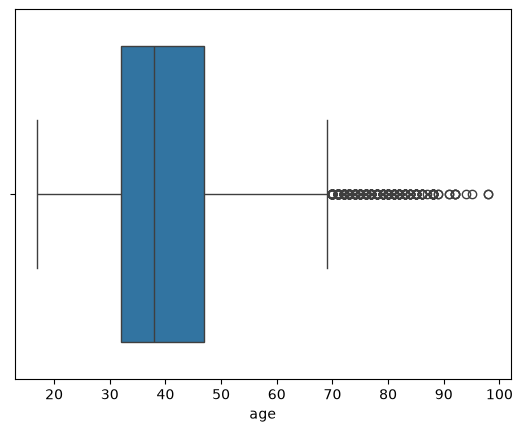

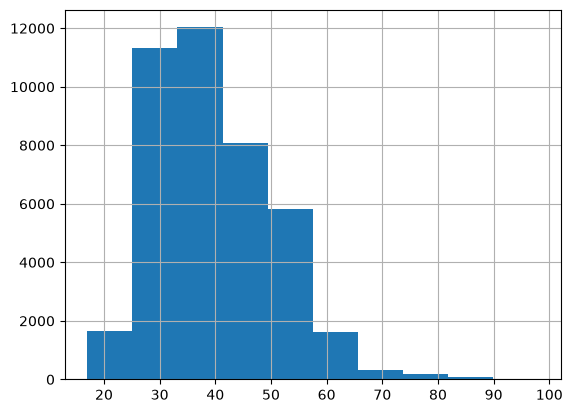

there are 2963 outliers in the column 'duration'
Outlier Counts: {1666: 1, 787: 9, 812: 6, 1575: 1, 1042: 4, 1467: 2, 849: 6, 677: 4, 2033: 1, 843: 8, 673: 11, 717: 9, 683: 7, 1077: 4, 730: 10, 702: 7, 962: 2, 935: 7, 742: 12, 669: 7, 680: 9, 1201: 2, 1030: 4, 769: 4, 744: 17, 1623: 1, 678: 7, 699: 10, 1677: 1, 918: 3, 792: 8, 1297: 2, 695: 11, 1906: 1, 802: 6, 739: 6, 1597: 1, 716: 12, 1529: 2, 800: 10, 720: 12, 852: 3, 992: 5, 732: 8, 1521: 1, 1138: 3, 786: 8, 799: 6, 866: 1, 1581: 1, 650: 9, 1101: 3, 912: 2, 1062: 4, 688: 6, 803: 5, 1009: 4, 764: 8, 1273: 1, 1574: 2, 984: 10, 1689: 2, 865: 2, 944: 3, 813: 8, 1119: 2, 1120: 5, 784: 5, 665: 10, 712: 13, 1007: 4, 789: 5, 756: 7, 989: 2, 1170: 1, 807: 4, 2087: 1, 767: 8, 1178: 4, 956: 6, 985: 3, 672: 6, 886: 4, 1187: 4, 826: 4, 847: 6, 659: 14, 772: 9, 929: 2, 710: 4, 705: 14, 2462: 2, 1132: 3, 825: 9, 646: 5, 653: 9, 654: 13, 1087: 3, 1692: 1, 2016: 2, 1054: 1, 1713: 1, 663: 11, 1080: 5, 1461: 2, 750: 5, 878: 6, 834: 9, 1534: 1, 836: 6

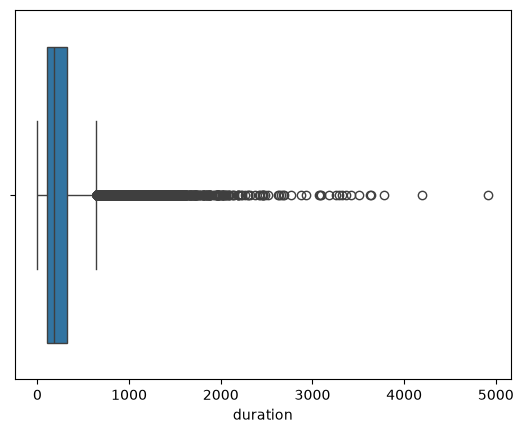

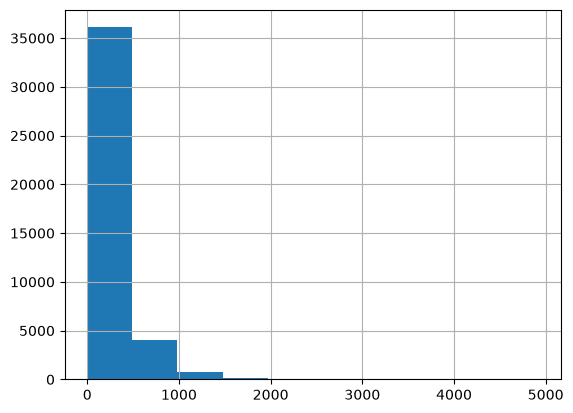

there are 2406 outliers in the column 'campaign'
Outlier Counts: {7: 629, 8: 400, 9: 283, 10: 225, 11: 177, 12: 125, 13: 92, 19: 26, 18: 33, 23: 16, 14: 69, 22: 17, 25: 8, 16: 51, 17: 58, 15: 51, 20: 30, 56: 1, 39: 1, 35: 5, 42: 2, 28: 8, 26: 8, 27: 11, 32: 4, 21: 24, 24: 15, 29: 10, 31: 7, 30: 7, 41: 1, 37: 1, 40: 2, 33: 4, 34: 3, 43: 2}


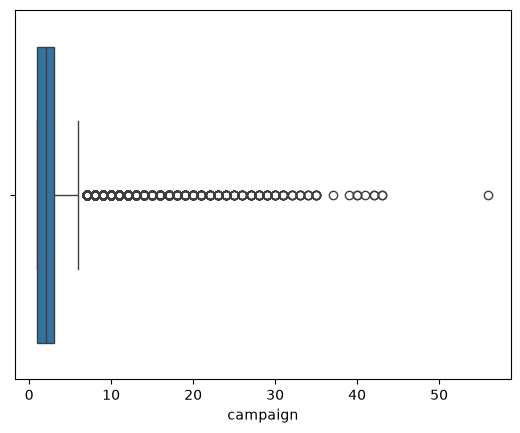

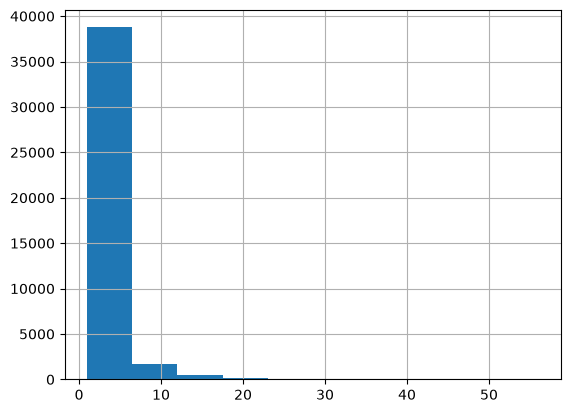

there are 82 outliers in the column 'pdays'
Outlier Counts: {14.0: 20, 15.0: 24, 16.0: 11, 21.0: 2, 17.0: 8, 18.0: 7, 22.0: 3, 25.0: 1, 26.0: 1, 19.0: 3, 27.0: 1, 20.0: 1}


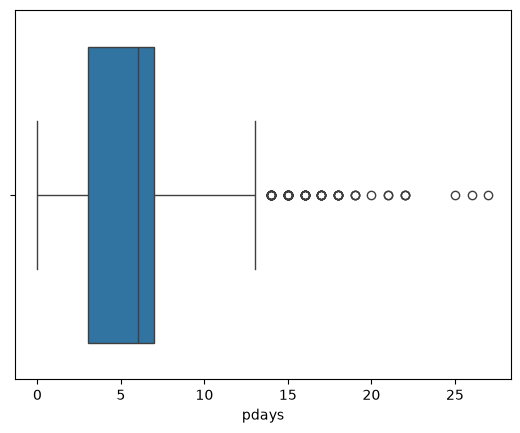

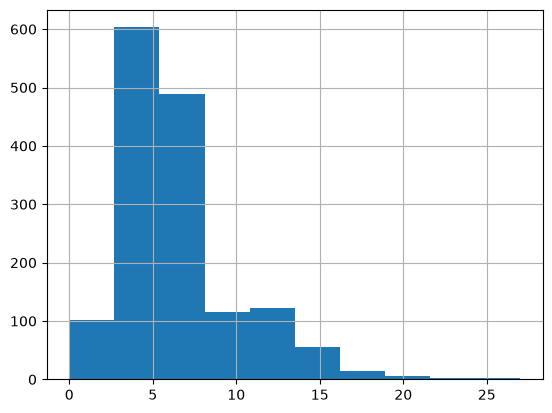

there are 5621 outliers in the column 'previous'
Outlier Counts: {1: 4559, 2: 754, 3: 216, 4: 69, 5: 18, 6: 4, 7: 1}


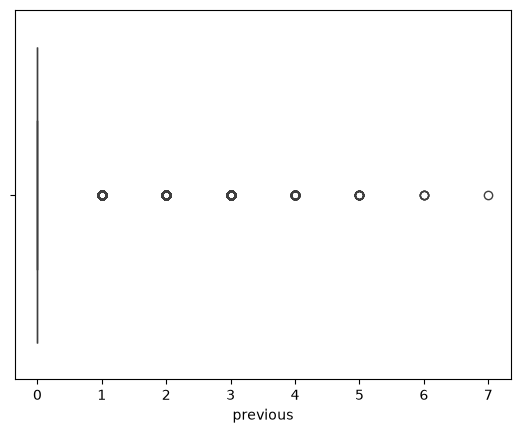

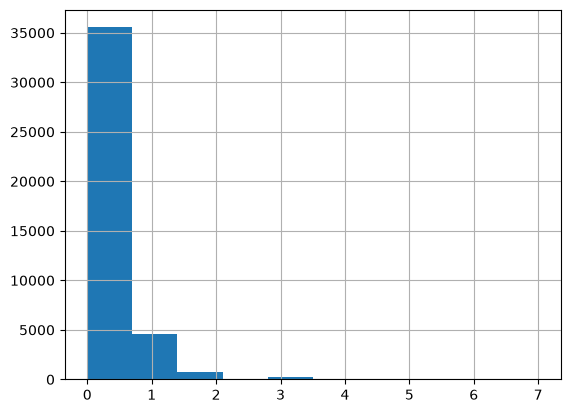

there are 446 outliers in the column 'cons.conf.idx'
Outlier Counts: {-26.9: 446}


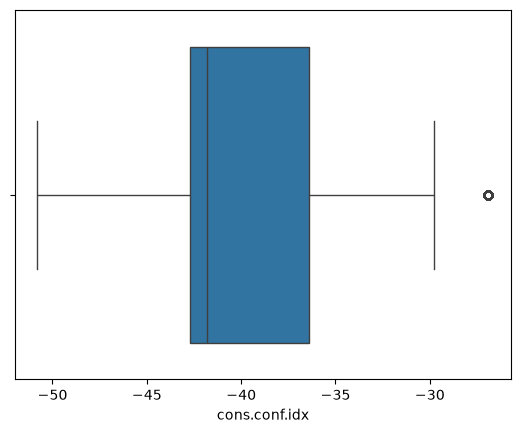

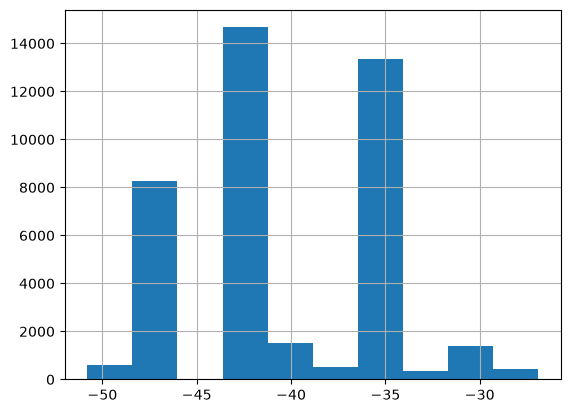

In [107]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.select_dtypes(include=['int64', 'float64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    outliers = df[
        (df[col] < Q1 - 1.5 * IQR) |
        (df[col] > Q3 + 1.5 * IQR)]
    if len(outliers) > 0:
        print(f"there are {len(outliers)} outliers in the column '{col}'")
        counts = Counter(outliers[col])
        print("Outlier Counts:", dict(counts))
        sns.boxplot(x=df[col])
        plt.show()
        df[col].hist()
        plt.show()

In [108]:
import csv
with open(FIX_INVALID_DATA_LINK, "w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)

    writer.writerow(df.columns)

    for row in df.itertuples(index=False):
        writer.writerow(row)